# Tier A+B Tropical Cyclone Tracks and Maximum Sustained Wind

## tl;dr

The final 2022–2024 main-track Tier A+B sample contains **83 tropical cyclones**. Track colors map point-level `USA_WIND` values (kt) with the continuous `coolwarm` colormap; warmer colors indicate higher wind speeds.

## Context & Methods

### Key Assumptions

- The A+B sample is defined by `tier ∈ {A, B}` in `final_main_primary_coastal_impact_cases.csv`.
- Only original observations from each storm's `TRACK_TYPE_NORMALIZED == "main"` track are retained.
- Each path segment is colored by the mean `USA_WIND` value of its two endpoints; missing wind values are interpolated within each storm.
- Longitude is locally unwrapped at the international date line so tracks remain continuous across 180° without drawing across the map.

## Data

### 1. Setup and parameters

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd


ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
CATALOG_DIR = ROOT / "outputs" / "coastal_catalog_2022_2024"
CASE_PATH = CATALOG_DIR / "final_main_primary_coastal_impact_cases.csv"
TRACK_PATH = CATALOG_DIR / "coastal_track_points.csv.gz"
OUTPUT_PATH = ROOT / "reports" / "figures" / "ab_typhoon_tracks.tif"

WIND_MIN_KT = 10
WIND_MAX_KT = 165
CMAP = "coolwarm"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans"],
    "font.size": 16,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.unicode_minus": False,
})

### 2. Load and validate the A+B sample

In [2]:
cases = pd.read_csv(CASE_PATH, keep_default_na=False)
ab_cases = cases[cases["tier"].isin(["A", "B"])].copy()
storm_ids = set(ab_cases["storm_id"])

tracks = pd.read_csv(
    TRACK_PATH,
    usecols=[
        "storm_id", "ISO_TIME", "LAT", "LON", "USA_WIND",
        "is_original_point", "TRACK_TYPE_NORMALIZED",
    ],
)
ab_tracks = tracks[
    tracks["storm_id"].isin(storm_ids)
    & tracks["is_original_point"]
    & tracks["TRACK_TYPE_NORMALIZED"].eq("main")
].copy()

summary = pd.Series({
    "A episodes": int((ab_cases["tier"] == "A").sum()),
    "B episodes": int((ab_cases["tier"] == "B").sum()),
    "unique storms": len(storm_ids),
    "original track points": len(ab_tracks),
    "wind coverage": f"{ab_tracks['USA_WIND'].notna().mean():.1%}",
})
summary.to_frame("value")

,value
A episodes,83
B episodes,31
unique storms,83
original track points,6561
wind coverage,88.9%


### 3. Count storms by basin

In [3]:
basin_counts = (
    ab_cases.groupby("basin", as_index=False)
    .agg(
        storm_count=("storm_id", "nunique"),
        episode_count=("case_id", "size"),
    )
    .sort_values(["storm_count", "episode_count"], ascending=False)
    .reset_index(drop=True)
)

print("Tier A+B sample counts by basin:")
print(basin_counts.to_string(index=False))
print(f"\nUnique storms across all basins: {ab_cases['storm_id'].nunique()}")
print(f"Total coastal-impact episodes: {len(ab_cases)}")

Tier A+B sample counts by basin:
basin  storm_count  episode_count
   WP           32             44
   NA           17             28
   EP           13             15
   SI           10             15
   NI            6              7
   SP            5              5

Unique storms across all basins: 83
Total coastal-impact episodes: 114


### 4. Convert observations to colored path segments

In [4]:
def track_segments(track):
    track = track.sort_values("ISO_TIME").copy()
    track["wind"] = track["USA_WIND"].interpolate(limit_direction="both")
    coordinates = track[["LON", "LAT"]].to_numpy(float)
    winds = track["wind"].to_numpy(float)

    segments, values = [], []
    for index in range(len(coordinates) - 1):
        start = coordinates[index].copy()
        end = coordinates[index + 1].copy()
        if not np.isfinite(np.r_[start, end]).all():
            continue

        longitude_jump = end[0] - start[0]
        if longitude_jump > 180:
            end[0] -= 360
        elif longitude_jump < -180:
            end[0] += 360

        value = np.nanmean(winds[index:index + 2])
        if np.isfinite(value):
            segments.append(np.vstack([start, end]))
            values.append(float(value))
    return segments, values


all_segments, all_winds = [], []
for _, storm_track in ab_tracks.groupby("storm_id", sort=False):
    segments, winds = track_segments(storm_track)
    all_segments.extend(segments)
    all_winds.extend(winds)

pd.Series(all_winds).describe().to_frame("segment wind (kt)")

,segment wind (kt)
count,6478.000000
mean,56.322476
std,31.421917
min,10.000000
25%,30.000000
50%,49.000000
75%,75.000000
max,164.000000


## Results

### 5. Plot the global tracks

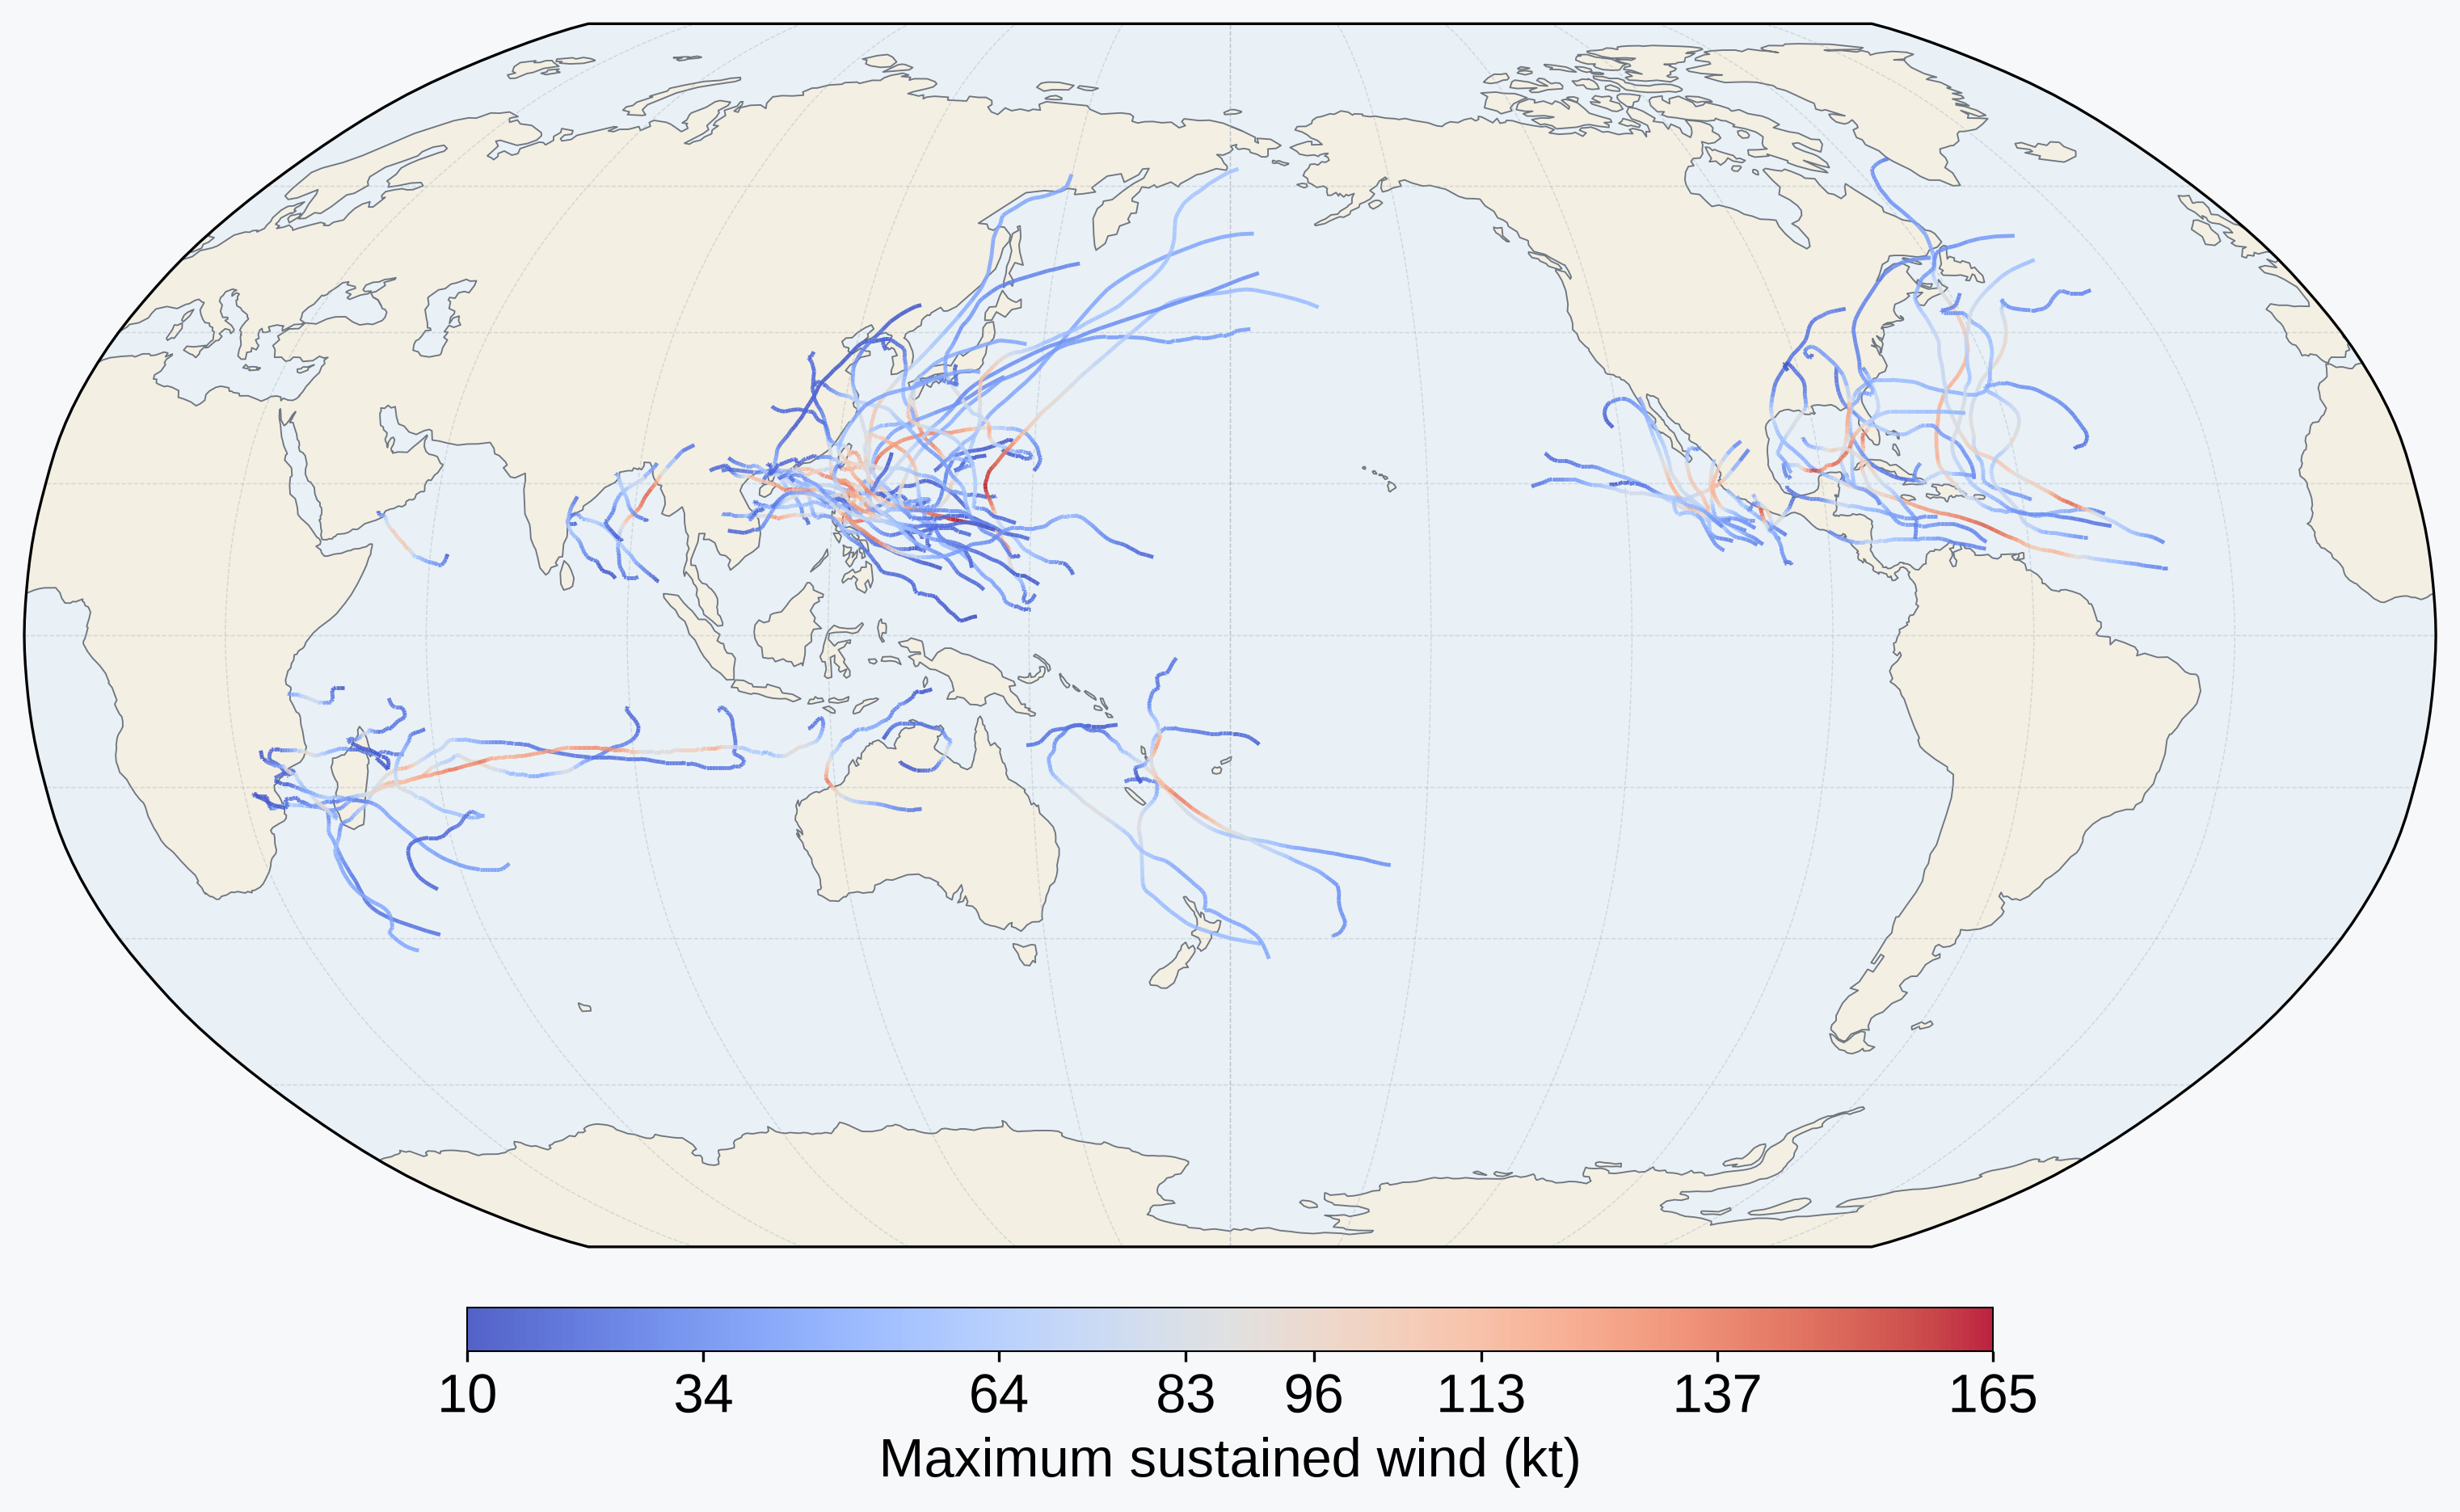

Saved: /data/users/hufeng/ai_weather_eval/reports/figures/ab_typhoon_tracks.tif


In [5]:
projection = ccrs.Robinson(central_longitude=180)
fig = plt.figure(figsize=(14, 7.2), facecolor="#f7f8fa")
ax = plt.axes(projection=projection)
ax.set_global()
ax.set_facecolor("#e9f1f7")
ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#f3efe3", zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), edgecolor="#6f7680", linewidth=0.45, zorder=1)
# ax.add_feature(cfeature.BORDERS.with_scale("110m"), edgecolor="#a9adb3", linewidth=0.25, zorder=1)
ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.35,
    color="#9da7b1", alpha=0.35, linestyle="--",
    xlocs=np.arange(-180, 181, 30), ylocs=np.arange(-60, 61, 20),
)

norm = mpl.colors.Normalize(vmin=WIND_MIN_KT, vmax=WIND_MAX_KT)
collection = LineCollection(
    all_segments, cmap=CMAP, norm=norm, linewidths=1.15, alpha=0.88,
    transform=ccrs.PlateCarree(), zorder=2,
)
collection.set_array(np.asarray(all_winds))
ax.add_collection(collection)

colorbar = fig.colorbar(collection, ax=ax, orientation="horizontal", fraction=0.045, pad=0.045, shrink=0.58, aspect=35)
colorbar.set_label("Maximum sustained wind (kt)")
colorbar.set_ticks([10, 34, 64, 83, 96, 113, 137, 165])
colorbar.ax.tick_params(length=3)
colorbar.outline.set_linewidth(0.5)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    OUTPUT_PATH,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    pil_kwargs={"compression": "tiff_lzw"},
)
plt.show()

print(f"Saved: {OUTPUT_PATH}")

## Takeaways

- Tracks are concentrated in the western North Pacific, North Atlantic, South Indian Ocean, and South Pacific.
- High-wind, warm-colored segments generally occur during the mature stages of storms, with visible intensity changes around coastal approaches.
- Colors represent wind speed for each path segment, rather than one lifetime maximum applied uniformly to an entire storm.